# 01 - Exploratory data analysis

**Goal:** understand the SBA 7(a)/504 loan book, the default label, and which cuts of the portfolio carry risk,
*before* modelling. Everything here uses the **training window only (FY2010-FY2016)** for anything that will
influence modelling decisions, so the validation and test vintages stay untouched. The one exception is the
by-vintage default-rate chart, which deliberately spans all years to show the economic-cycle drift.

> **Data note.** If `data/raw/real/` contains the SBA FOIA CSVs they are used. Otherwise the pipeline falls back to
> the synthetic FOIA-schema stand-in (`src/synthetic.py`) - the build sandbox could not reach sba.gov. The banner
> printed below says which one is loaded. Numbers computed on the synthetic stand-in demonstrate the *method*; they are not
> findings about real SBA borrowers.

In [1]:
import sys
sys.path.insert(0, "..")
import warnings; warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import config, data_prep, evaluation, features, train
from src.evaluation import PALETTE, save_fig, set_style

set_style()
pd.options.display.float_format = "{:,.3f}".format
pd.options.display.max_columns = 40

src_kind = train.data_source()
display(Markdown(f"**Data source loaded: `{src_kind.upper()}`**" + (" - synthetic FOIA-schema stand-in (see note above)" if src_kind == "synthetic" else " - real SBA FOIA extracts")))

**Data source loaded: `SYNTHETIC`** - synthetic FOIA-schema stand-in (see note above)

## 1. Raw data, target definition and sample attrition

**Target (exact rule, also in `docs/DATA_DICTIONARY.md`):**

* `default = 1` if `LoanStatus == "CHGOFF"` **and** `ChargeOffDate <= FirstDisbursementDate + 36 months`; otherwise `0`.
* Only loans with `LoanStatus in {PIF, CHGOFF, EXEMPT}` (paid in full / charged off / in force) are kept - cancelled and
  committed-but-unfunded loans never had a chance to default.
* Only loans whose full 36-month window has elapsed before the extract date (`AS_OF_DATE`) are labelled. Younger loans are
  **right-censored**: a loan disbursed 10 months ago that has not defaulted is *not* a good loan, it is an unknown. Labelling
  it 0 would bias default rates downward for the most recent vintages.
* Charge-offs that happen *after* month 36 are labelled 0 for this target (they are counted below so the effect is visible).

In [2]:
raw = data_prep.load_raw()
df, stats = data_prep.build_target(raw)
attrition = pd.DataFrame({
    "step": ["Raw rows (7(a) + 504)", "Keep status PIF / CHGOFF / EXEMPT", "Have approval + first-disbursement dates",
             "Full 36-month window observed by as-of date", ],
    "rows": [stats["raw_rows"], stats["after_status_filter"], stats["after_disbursement_filter"], stats["after_censoring_filter"]],
})
attrition["dropped"] = -attrition["rows"].diff().fillna(0).astype(int)
display(attrition)
print(f"Charge-offs occurring after month 36 (labelled 0): {stats['late_chargeoffs_labelled_0']:,}")
print("Status mix in raw data:"); display(raw["LoanStatus"].value_counts().to_frame("loans"))

,step,rows,dropped
0,Raw rows (7(a) + 504),133200,0
1,Keep status PIF / CHGOFF / EXEMPT,127851,5349
2,Have approval + first-disbursement dates,127851,0
3,Full 36-month window observed by as-of date,105916,21935


Charge-offs occurring after month 36 (labelled 0): 3,262
Status mix in raw data:


,loans
LoanStatus,
EXEMPT,62159
PIF,53484
CHGOFF,12208
CANCLD,5349


## 2. Class balance and the vintage effect

Defaults are a minority class (single-digit %), so accuracy is a useless metric - we will use AUC/KS/Gini for ranking and
Brier/calibration for the probabilities. The right panel is the reason the validation is **out-of-time**: the default rate of
a vintage moves with the economic cycle (post-crisis 2010, benign mid-decade, COVID 2020), so a random split would
leak the future cycle into training.

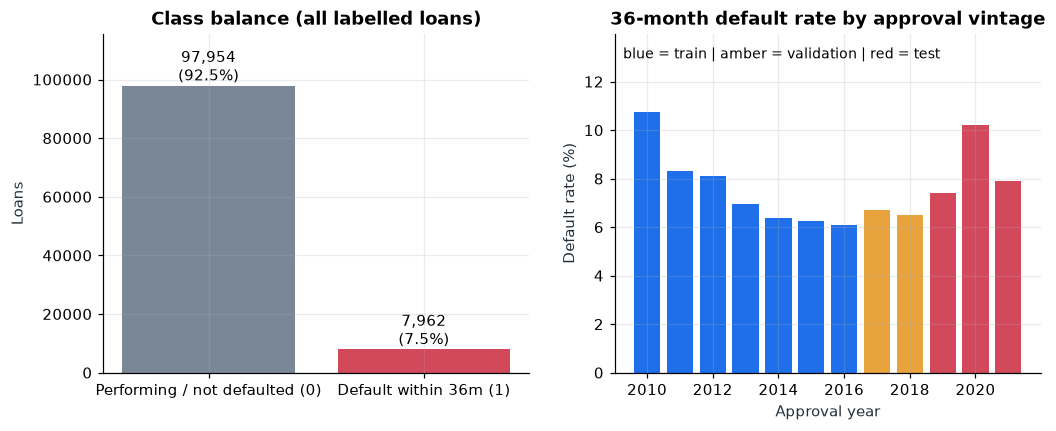

approval_year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
loans,"6,058.000","6,485.000","7,330.000","7,744.000","8,193.000","8,628.000","9,066.000","9,522.000","9,959.000","9,963.000","8,188.000","11,639.000"
default_rate,0.107,0.083,0.081,0.070,0.064,0.062,0.061,0.067,0.065,0.074,0.102,0.079


In [3]:
train_df, valid_df, test_df = data_prep.split_by_vintage(df)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = df["default"].value_counts().sort_index()
ax[0].bar(["Performing / not defaulted (0)", "Default within 36m (1)"], counts.values, color=[PALETTE["lr"], PALETTE["bad"]])
for i, v in enumerate(counts.values):
    ax[0].text(i, v, f"{v:,}\n({v / counts.sum():.1%})", ha="center", va="bottom")
ax[0].set(title="Class balance (all labelled loans)", ylabel="Loans"); ax[0].set_ylim(0, counts.max() * 1.18)

by_year = df.groupby("approval_year")["default"].agg(["size", "mean"]).loc[:config.TEST_YEARS[1]]  # 2022+ vintages are only partly observed and unused
colors = [PALETTE["gbm"] if y <= config.TRAIN_YEARS[1] else PALETTE["accent"] if y <= config.VALID_YEARS[1] else PALETTE["bad"] for y in by_year.index]
ax[1].bar(by_year.index, by_year["mean"] * 100, color=colors)
ax[1].set(title="36-month default rate by approval vintage", ylabel="Default rate (%)", xlabel="Approval year")
ax[1].set_ylim(0, by_year["mean"].max() * 130); ax[1].text(0.02, 0.96, "blue = train | amber = validation | red = test", transform=ax[1].transAxes, va="top", fontsize=9)
save_fig(fig, "eda_class_balance_vintage"); plt.show()
display(by_year.rename(columns={"size": "loans", "mean": "default_rate"}).T)

## 3. Missingness

Missing values are not random in SBA data: some fields (e.g. `CollateralInd`, `BusinessAge`) were not collected or were
"Unanswered" in earlier years. The modelling pipeline therefore imputes (median for numerics **plus a missing-indicator**,
constant `MISSING` category for text) - inside the sklearn Pipeline so statistics come from training data only.

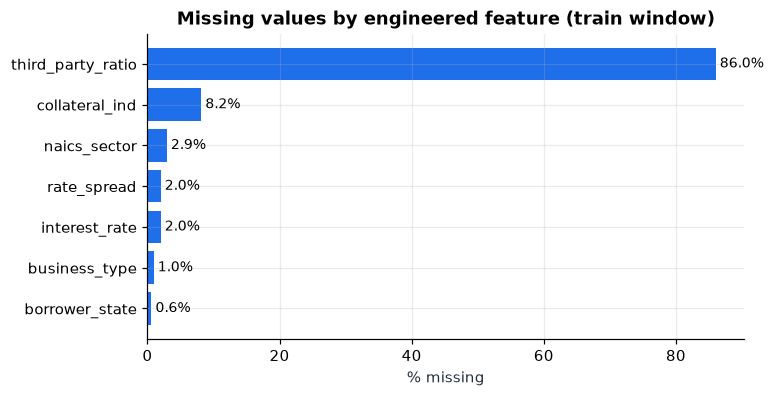

`third_party_ratio` is structurally missing for 7(a) loans (only 504 loans have a third-party lender share).


In [4]:
X_train = features.make_features(train_df)
miss = X_train.isna().mean().sort_values(ascending=True)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(miss.index, miss.values * 100, color=PALETTE["gbm"])
ax.set(title="Missing values by engineered feature (train window)", xlabel="% missing")
for i, v in enumerate(miss.values):
    ax.text(v * 100, i, f" {v:.1%}", va="center", fontsize=9)
save_fig(fig, "eda_missingness"); plt.show()
print("`third_party_ratio` is structurally missing for 7(a) loans (only 504 loans have a third-party lender share).")

## 4. Key distributions

Loan size is heavily right-skewed, so we model `log(GrossApproval)`. `rate_spread` = initial rate minus the prime rate in force in the
approval year - a de-trended price that is comparable across rate environments.

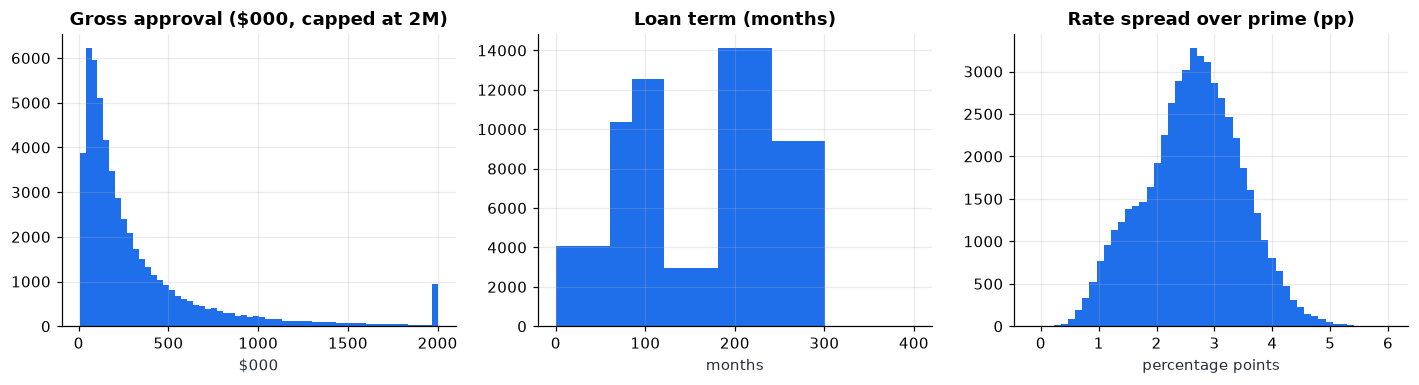

,count,mean,std,min,25%,50%,75%,max
GrossApproval,"53,504.000","341,259.599","492,000.487","5,000.000","89,200.000","184,450.000","388,725.000","5,000,000.000"
TermInMonths,"53,504.000",175.099,84.755,60.000,84.000,120.000,240.000,300.000
InitialInterestRate,"52,428.000",5.924,0.843,3.098,5.364,5.951,6.503,9.395
JobsSupported,"53,504.000",7.263,8.807,0.000,2.000,5.000,9.000,237.000


In [5]:
tr = train_df.reset_index(drop=True)
Xt = X_train.reset_index(drop=True)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].hist(tr["GrossApproval"].clip(upper=2e6) / 1e3, bins=60, color=PALETTE["gbm"]); ax[0].set(title="Gross approval ($000, capped at 2M)", xlabel="$000")
ax[1].hist(tr["TermInMonths"], bins=[0, 61, 85, 121, 181, 241, 301, 400], color=PALETTE["gbm"]); ax[1].set(title="Loan term (months)", xlabel="months")
ax[2].hist(Xt["rate_spread"].dropna(), bins=50, color=PALETTE["gbm"]); ax[2].set(title="Rate spread over prime (pp)", xlabel="percentage points")
fig.tight_layout(); save_fig(fig, "eda_distributions"); plt.show()
display(tr[["GrossApproval", "TermInMonths", "InitialInterestRate", "JobsSupported"]].describe().T)

## 5. Default rate by the cuts that matter
A helper draws default rate by category with a volume bar behind it, so a scary-looking rate on 30 loans is not mistaken for signal.

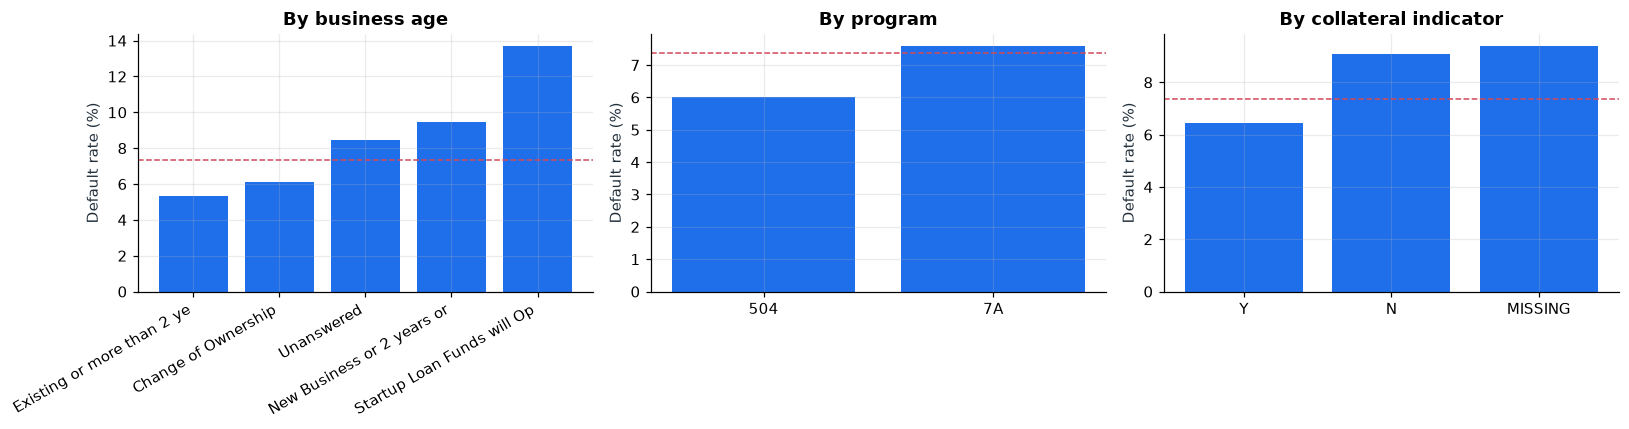

,loans,default_rate
g,,
Existing or more than 2 ye,23801,0.053
Change of Ownership,8073,0.061
Unanswered,7382,0.085
New Business or 2 years or,9539,0.095
Startup Loan Funds will Op,4709,0.137


In [6]:
def default_rate_by(series, title, ax, min_n=300, top=None, order=None, rotate=0):
    d = pd.DataFrame({"g": series.to_numpy(), "y": tr["default"].to_numpy()})
    t = d.groupby("g", observed=True)["y"].agg(["size", "mean"])
    t = t[t["size"] >= min_n]
    if top:
        t = t.sort_values("size", ascending=False).head(top)
    t = t.loc[[o for o in order if o in t.index]] if order is not None else t.sort_values("mean")
    ax.bar(range(len(t)), t["mean"] * 100, color=PALETTE["gbm"])
    ax.axhline(tr["default"].mean() * 100, color=PALETTE["bad"], ls="--", lw=1)
    ax.set_xticks(range(len(t))); ax.set_xticklabels([str(i) for i in t.index], rotation=rotate, ha="right" if rotate else "center")
    ax.set(title=title, ylabel="Default rate (%)")
    return t

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
t_age = default_rate_by(Xt["business_age"].str.replace("_", " ").str.slice(0, 26), "By business age", ax[0], rotate=30)
t_prog = default_rate_by(Xt["program"], "By program", ax[1])
t_col = default_rate_by(Xt["collateral_ind"].fillna("MISSING"), "By collateral indicator", ax[2])
fig.tight_layout(); save_fig(fig, "eda_default_by_business_age"); plt.show()
display(t_age.rename(columns={"size": "loans", "mean": "default_rate"}))

### Industry (NAICS 2-digit sector)
Sector is one of the strongest business-story cuts: accommodation & food (72), construction (23) and arts/recreation (71) run above the
portfolio average; health care (62), real estate (53) and professional services (54) run below.

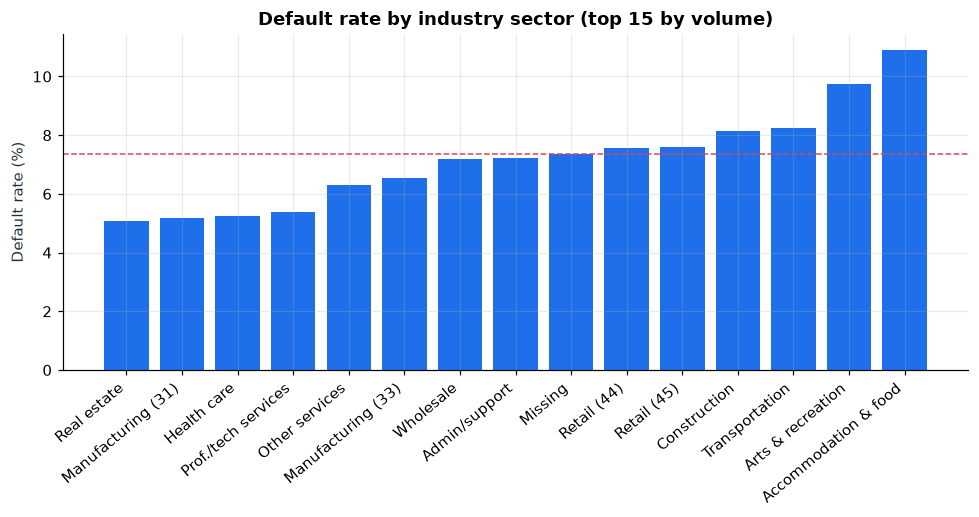

In [7]:
NAICS = {"72": "Accommodation & food", "23": "Construction", "44": "Retail (44)", "45": "Retail (45)", "62": "Health care", "54": "Prof./tech services",
         "81": "Other services", "33": "Manufacturing (33)", "48": "Transportation", "53": "Real estate", "56": "Admin/support",
         "71": "Arts & recreation", "42": "Wholesale", "11": "Agriculture", "61": "Education", "31": "Manufacturing (31)", "32": "Manufacturing (32)"}
sect = Xt["naics_sector"].map(lambda s: NAICS.get(s, s) if isinstance(s, str) else "Missing")
fig, ax = plt.subplots(figsize=(9, 4.8))
t = default_rate_by(sect, "Default rate by industry sector (top 15 by volume)", ax, top=15, rotate=40)
fig.tight_layout(); save_fig(fig, "eda_default_by_sector"); plt.show()

### Loan size, term and price
Small and short-term loans default more often; loans priced far above prime carry more risk (the lender saw some of it) - but price alone
is a weak separator, which is why we need a multivariate model.

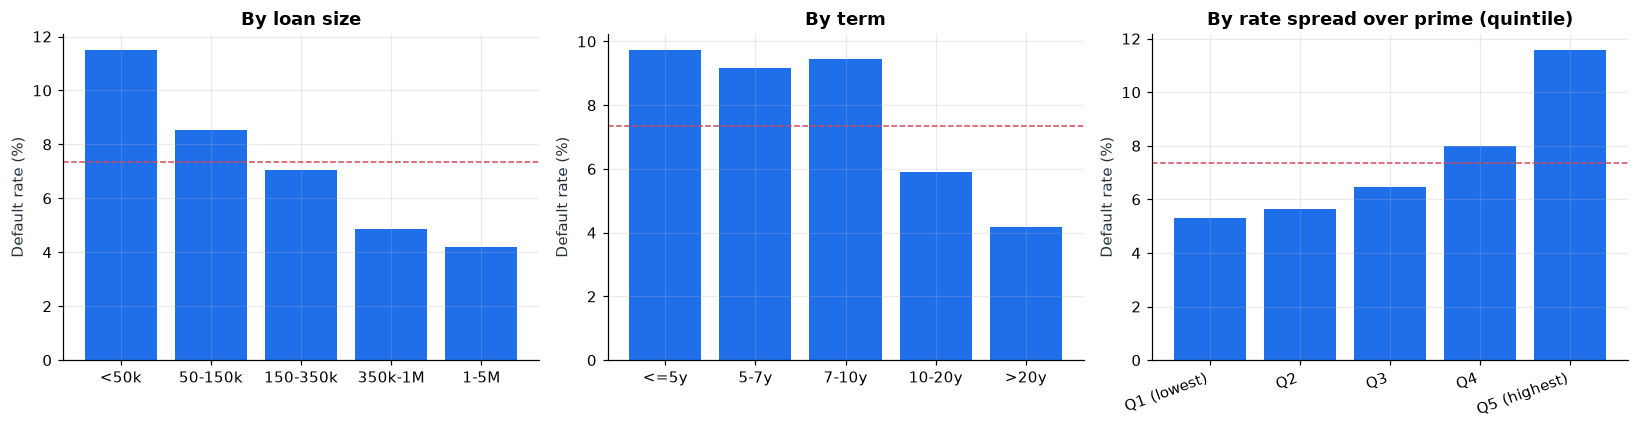

In [8]:
size_band = pd.cut(tr["GrossApproval"], [0, 50e3, 150e3, 350e3, 1e6, 5e6, 1e9], labels=["<50k", "50-150k", "150-350k", "350k-1M", "1-5M", ">5M"])
term_band = pd.cut(tr["TermInMonths"], [0, 60, 84, 120, 240, 400], labels=["<=5y", "5-7y", "7-10y", "10-20y", ">20y"])
spread_band = pd.qcut(Xt["rate_spread"], 5, labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"])
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
default_rate_by(size_band, "By loan size", ax[0], order=list(size_band.cat.categories))
default_rate_by(term_band, "By term", ax[1], order=list(term_band.cat.categories))
default_rate_by(spread_band, "By rate spread over prime (quintile)", ax[2], order=list(spread_band.cat.categories), rotate=20)
fig.tight_layout(); save_fig(fig, "eda_default_by_size_term_price"); plt.show()

### Geography
State effects exist but are modest compared with age/industry/size; many small states have too few loans to read (filtered at n>=300).

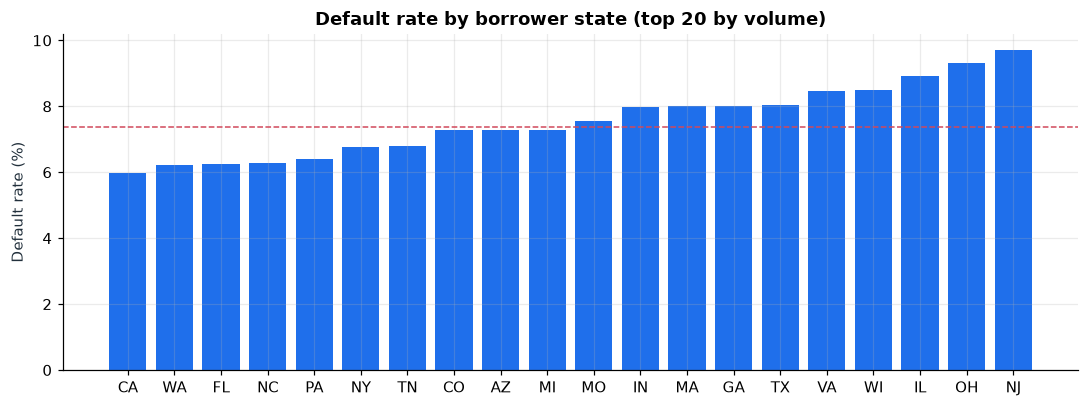

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.8))
default_rate_by(Xt["borrower_state"], "Default rate by borrower state (top 20 by volume)", ax, top=20, rotate=0)
fig.tight_layout(); save_fig(fig, "eda_default_by_state"); plt.show()

### Bivariate interaction: business age x industry
Risk factors compound. Start-up restaurants/hotels are far riskier than either factor alone suggests - a non-additive effect that
logistic regression can only capture with hand-built interaction terms and that gradient boosting finds automatically.

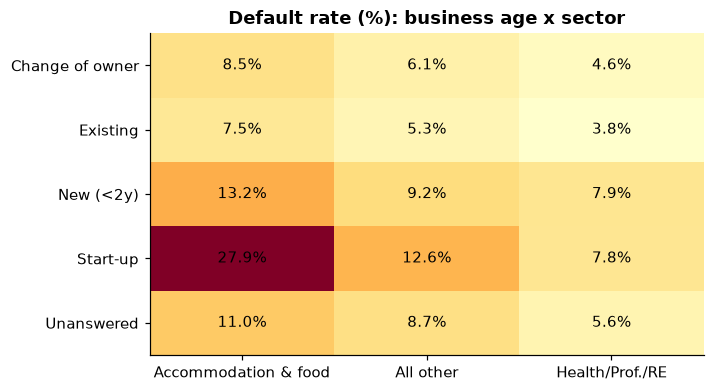

In [10]:
tmp = pd.DataFrame({"age": Xt["business_age"].str.split("_").str[0].replace({"Existing": "Existing", "New": "New (<2y)", "Startup": "Start-up", "Change": "Change of owner", "Unanswered": "Unanswered"}),
                    "sector": np.where(Xt["naics_sector"] == "72", "Accommodation & food", np.where(Xt["naics_sector"].isin(["62", "54", "53"]), "Health/Prof./RE", "All other")),
                    "y": tr["default"]})
pt = tmp.pivot_table(index="age", columns="sector", values="y", aggfunc="mean") * 100
fig, ax = plt.subplots(figsize=(6.5, 3.8))
im = ax.imshow(pt.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(pt.shape[1])); ax.set_xticklabels(pt.columns); ax.set_yticks(range(pt.shape[0])); ax.set_yticklabels(pt.index)
for i in range(pt.shape[0]):
    for j in range(pt.shape[1]):
        ax.text(j, i, f"{pt.values[i, j]:.1f}%", ha="center", va="center")
ax.set(title="Default rate (%): business age x sector"); ax.grid(False)
save_fig(fig, "eda_interaction_age_sector"); plt.show()

## 6. Leakage control - **features excluded due to leakage risk, and why**

A PD model may only use what is known **on the approval date**. SBA FOIA files mix origination attributes with post-origination
outcome fields in the same row. Using an outcome field as a "feature" gives spectacular but meaningless accuracy. The table lists every
column excluded and the reason; `features.assert_no_leakage` enforces it in code and a unit test guards it.

In [11]:
display(pd.DataFrame({"excluded raw field": list(features.LEAKAGE_EXCLUDED), "why it is leakage": list(features.LEAKAGE_EXCLUDED.values())}).style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

excluded raw field,why it is leakage
LoanStatus,Outcome itself (PIF / CHGOFF / ...). Encodes the label directly.
ChargeOffDate,Only exists once the loan has defaulted; the target is derived from it.
GrossChargeOffAmount,Loss amount realised after default; non-null only for defaulted loans.
PaidInFullDate,"Only exists after the loan has repaid - a 'survivor' marker, known post-origination."
SoldSecMrktInd,"Secondary-market sale happens after origination, and investors buy performing loans."
AsOfDate,"Extract date, not a borrower attribute; constant per file and correlates with loan age."
FirstDisbursementDate,"Used ONLY to anchor the 36-month outcome window, never as a feature: disbursement happens after approval (approval->disbursement lag is post-decision)."
ApprovalDate/approval_year,Used ONLY for the out-of-time split and to de-trend the rate; the raw calendar year is not a feature (a model must not memorise vintages).
BorrName / address / bank identifiers,"Free-text / identifiers: memorisation risk, no generalisable signal, PII-adjacent. (Lender identity is a legitimate future feature - see README.)"
"Loan age, remaining balance, delinquency, servicing flags",Not in the origination record; would only exist post-approval.


**Demonstration - why it matters.** A "model" that simply uses fields that only exist post-outcome is near-perfect. This is the trap
the exclusion list avoids.

In [12]:
from sklearn.metrics import roc_auc_score
demo = pd.DataFrame({
    "'Feature' (post-outcome field)": ["GrossChargeOffAmount is not null", "LoanStatus == CHGOFF", "PaidInFullDate is null (loan not repaid)"],
    "AUC vs 36m default flag": [
        roc_auc_score(tr["default"], tr["GrossChargeOffAmount"].notna()),
        roc_auc_score(tr["default"], (tr["LoanStatus"] == "CHGOFF")),
        roc_auc_score(tr["default"], tr["PaidInFullDate"].isna()),
    ]})
display(demo.style.hide(axis="index").format({"AUC vs 36m default flag": "{:.3f}"}))
print("Legitimate origination-time model AUCs are ~0.65-0.75 (see notebook 02) - anything near 1.0 is a red flag, not a triumph.")

'Feature' (post-outcome field),AUC vs 36m default flag
GrossChargeOffAmount is not null,0.979
LoanStatus == CHGOFF,0.979
PaidInFullDate is null (loan not repaid),0.830


Legitimate origination-time model AUCs are ~0.65-0.75 (see notebook 02) - anything near 1.0 is a red flag, not a triumph.


## 7. Takeaways that shape the modelling
1. **Class imbalance** (~7-8% defaults): evaluate with AUC/KS/Gini and calibration, not accuracy.
2. **Vintage drift is large** (default rate swings by several points across years) -> out-of-time validation is mandatory, and calibration must be checked on later vintages.
3. **Business age, industry, loan size/term, and collateral** are the main drivers; some effects are **interactions** -> compare a linear baseline to gradient boosting.
4. **Missingness** is informative and vintage-dependent -> impute inside the pipeline with missing indicators.
5. **Leakage** is the single biggest way to fool oneself with FOIA data -> explicit exclusion registry, guard and test.